In [10]:
import pyodbc

# Bağlantı bilgilerini tanımla
server = r'.\SQLEXPRESS' 
database = 'TMDB_MovieDB' 

conn_str = (
    f'DRIVER={{SQL Server}};'
    f'SERVER={server};'
    f'DATABASE={database};'
    f'Trusted_Connection=yes;'
)

try:
    conn = pyodbc.connect(conn_str)
    cursor = conn.cursor()
    print("Veri tabanına başarıyla bağlandın Berk!\n")

    # --- ANALİZ 1: En Yüksek Bütçeli Filmler ve Kâr Durumları ---
    print("-" * 30)
    print("ANALİZ 1: EN YÜKSEK BÜTÇELİ FİLMLER")
    cursor.execute("""
        SELECT TOP 10 title, budget, (revenue - budget) AS kar 
        FROM dbo.Movies WHERE budget > 0 AND revenue > 0 
        ORDER BY budget DESC
    """)
    for row in cursor:
        durum = "KÂR" if row.kar > 0 else "ZARAR"
        print(f"Film: {row.title[:30]:<30} | Bütçe: {row.budget:12,.0f} | Kâr: {row.kar:12,.0f} ({durum})")

    # --- ANALİZ 2: En Çok Zarar Eden Dev Bütçeli Filmler (Gişe Bombaları) ---
    print("\n" + "-" * 30)
    print("ANALİZ 2: YÜKSEK BÜTÇELİ AMA EN ÇOK ZARAR EDENLER")
    cursor.execute("""
        SELECT TOP 10 title, budget, (revenue - budget) AS kar 
        FROM dbo.Movies WHERE budget > 100000000 
        ORDER BY kar ASC
    """)
    for row in cursor:
        print(f"Film: {row.title[:30]:<30} | Bütçe: {row.budget:12,.0f} | Zarar: {row.kar:12,.0f}")

    # --- ANALİZ 3: Yatırımın Karşılığını En Çok Verenler (Kat Sayısı) ---
    print("\n" + "-" * 30)
    print("ANALİZ 3: BÜTÇESİNE ORANLA EN ÇOK KAZANDIRANLAR (ROI)")
    cursor.execute("""
        SELECT TOP 10 title, budget, (revenue / budget) AS kat_sayisi 
        FROM dbo.Movies WHERE budget > 100000 
        ORDER BY kat_sayisi DESC
    """)
    for row in cursor:
        print(f"Film: {row.title[:30]:<30} | Bütçe: {row.budget:12,.0f} | Katı: {row.kat_sayisi:,.1f}x")

except Exception as e:
    print(f"Hata oluştu: {e}")

finally:
    if 'conn' in locals():
        conn.close()

Veri tabanına başarıyla bağlandın Berk!

------------------------------
ANALİZ 1: EN YÜKSEK BÜTÇELİ FİLMLER
Film: Pirates of the Caribbean: On S | Bütçe:  380,000,000 | Kâr:  665,713,802 (KÂR)
Film: Pirates of the Caribbean: At W | Bütçe:  300,000,000 | Kâr:  661,000,000 (KÂR)
Film: Avengers: Age of Ultron        | Bütçe:  280,000,000 | Kâr: 1,125,403,694 (KÂR)
Film: Superman Returns               | Bütçe:  270,000,000 | Kâr:  121,081,192 (KÂR)
Film: Tangled                        | Bütçe:  260,000,000 | Kâr:  331,794,936 (KÂR)
Film: John Carter                    | Bütçe:  260,000,000 | Kâr:   24,139,100 (KÂR)
Film: Spider-Man 3                   | Bütçe:  258,000,000 | Kâr:  632,871,626 (KÂR)
Film: The Lone Ranger                | Bütçe:  255,000,000 | Kâr: -165,710,090 (ZARAR)
Film: Harry Potter and the Half-Bloo | Bütçe:  250,000,000 | Kâr:  683,959,197 (KÂR)
Film: The Dark Knight Rises          | Bütçe:  250,000,000 | Kâr:  834,939,099 (KÂR)

------------------------------
ANALİZ 

Analiz sonucu 'sonuclar/analiz_sonucu.txt' dosyasına kaydedildi.


C:\Users\HP\AppData\Local\Temp\ipykernel_19052\2889045552.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\HP\AppData\Local\Temp\ipykernel_19052\2889045552.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='profit', y='title', palette='magma')


Grafikler 'grafikler/' klasörüne başarıyla kaydedildi.


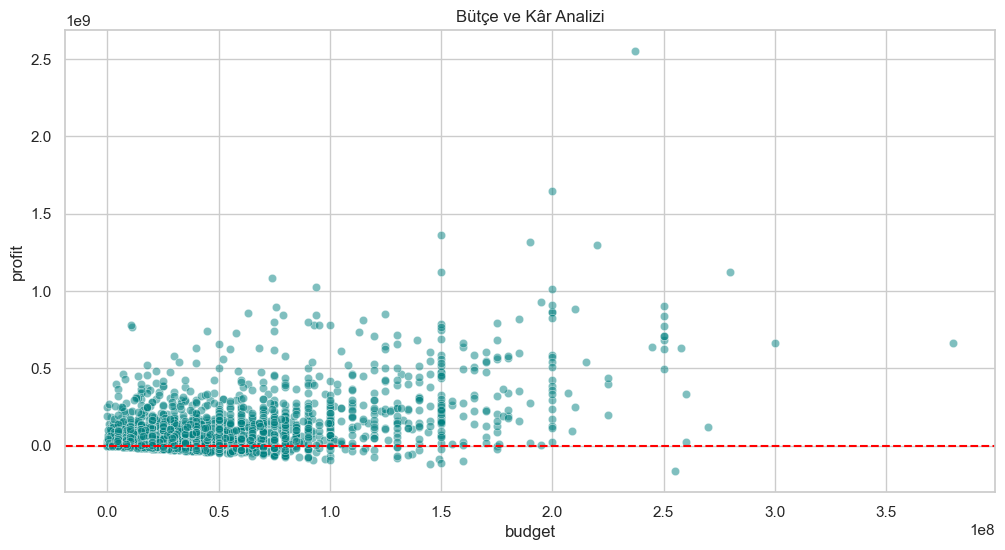

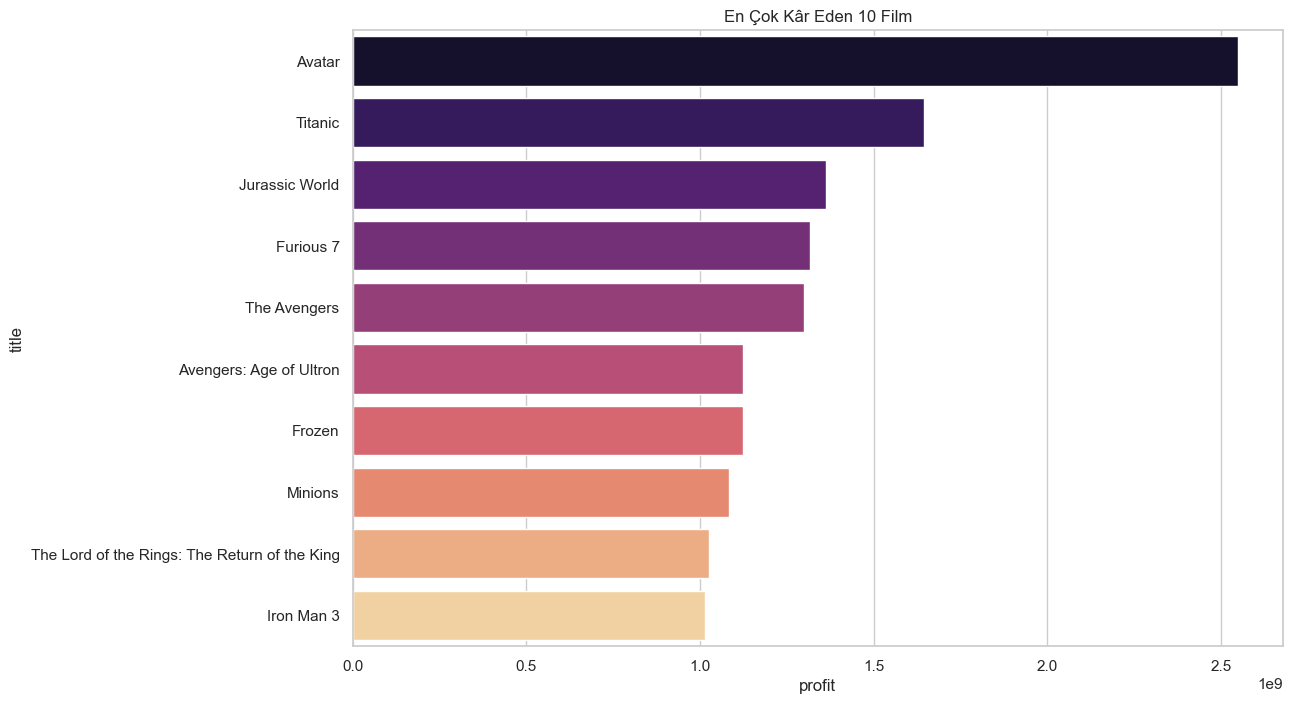

In [11]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Klasör Yapısını Hazırla
folders = ['grafikler', 'sonuclar']
for folder in folders:
    if not os.path.exists(folder):
        os.makedirs(folder)

# 2. Bağlantı Bilgileri
server = r'.\SQLEXPRESS'
database = 'TMDB_MovieDB'
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

try:
    # 3. Veriyi Çekme
    conn = pyodbc.connect(conn_str)
    query = """
    SELECT title, budget, revenue, (revenue - budget) AS profit 
    FROM Movies 
    WHERE budget > 0 AND revenue > 0
    """
    df = pd.read_sql(query, conn)
    conn.close()

    # --- ANALİZ VE TXT DOSYASI OLUŞTURMA ---
    high_budget_limit = 200000000
    high_budget_movies = df[df['budget'] >= high_budget_limit]
    loss_making = high_budget_movies[high_budget_movies['profit'] < 0]
    
    soru = "Soru: Büyük bütçeli filmler her zaman daha mı çok kâr elde ediyor?"
    cevap = ""
    
    if len(loss_making) > 0:
        cevap = f"Cevap: Hayır. Veri kümesindeki {len(high_budget_movies)} dev bütçeli filmden {len(loss_making)} tanesi zarar etmiştir.\n"
        cevap += f"En somut örnek: {loss_making.iloc[0]['title']} ({loss_making.iloc[0]['profit']:,.0f}$ zarar)."
    else:
        cevap = "Cevap: Dev bütçeli filmler genellikle yüksek hasılat yapsa da, kâr oranları düşük bütçeli kült filmlere göre çok daha verimsizdir."

    # Sonuçları txt olarak kaydet
    with open('sonuclar/analiz_sonucu.txt', 'w', encoding='utf-8') as f:
        f.write(f"{soru}\n\n{cevap}\n")
    
    print("Analiz sonucu 'sonuclar/analiz_sonucu.txt' dosyasına kaydedildi.")

    # --- GRAFİKLER ---
    sns.set_theme(style="whitegrid")
    
    # Grafik 1: Bütçe vs Kâr
    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=df, x='budget', y='profit', alpha=0.5, color='teal')
    plt.axhline(0, color='red', linestyle='--')
    plt.title('Bütçe ve Kâr Analizi')
    plt.savefig('grafikler/butce_kar_analizi.png')
    
    # Grafik 2: En Çok Kâr Edenler
    top_10 = df.sort_values(by='profit', ascending=False).head(10)
    plt.figure(figsize=(12, 8))
    sns.barplot(data=top_10, x='profit', y='title', palette='magma')
    plt.title('En Çok Kâr Eden 10 Film')
    plt.savefig('grafikler/en_cok_kar_edenler.png')

    print("Grafikler 'grafikler/' klasörüne başarıyla kaydedildi.")

except Exception as e:
    print(f"Hata: {e}")